In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
# re.sub('[^A-Za-z\s,]+', '', unidecode(x)).upper().strip())
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

### Rutas a los conjuntos de datos codificados
ht_file = r"C:\Users\mateo\Desktop\Google_Drive\UNIR\2_TFM\Datasets\Surv2_Schools\Datasets cruzados con PISA\Head_Teacher_con_datos_PISA.xlsx"
te_file = r"C:\Users\mateo\Desktop\Google_Drive\UNIR\2_TFM\Datasets\Surv2_Schools\Datasets cruzados con PISA\Teachers_con_datos_PISA.xlsx"
st_file = r"C:\Users\mateo\Desktop\Google_Drive\UNIR\2_TFM\Datasets\Surv2_Schools\Datasets cruzados con PISA\Students_con_datos_PISA.xlsx"

### Ruta al archivo de "analysis of variables" inicial
var_analysis = r"C:\Users\mateo\Desktop\Google_Drive\UNIR\2_TFM\Datasets\Surv2_Schools\Vars description\Vars_description.xlsx"

### Pestañas del archivo "analysis of variables"
ht_vars = "HT"
te_vars = "TE"
st_vars = "ST"

### Pestañas en los conjuntos de datos codificados
ht_tab = "ICT_Head_Teacher"
te_tab = "ICT_Teachers"
st_tab = "ICT_Students"

### Diccionarios para limpiar datasets
replace_values = {
    "CAT_DIC": [995, 997, 998, 999, " "],
    "CAT_ORD": [995, 997, 998, 999, " "],
    "CAT_NOM": [995, 997, 998, 999, " "],
    "NUM_INT": [999995, 999997, 999998, 999999, " "]
}

vars_dict = {
    "CAT_DIC": "Int64",
    "CAT_NOM": "Int64",
    "CAT_ORD": "Int64",
    "NUM_INT": "Int64",
    "NUM_CONT": "float64"
}

wt_ht = "FSTWT_2"
wt_te = "FSTWT"
wt_st = "FSTWT"

pisa_math = "PISA_Math"
pisa_science = "PISA_Science"
pisa_avg = "PISA_Media"

### Etiquetas de variables de pesos y de clústeres
aux_vars = ["FSCWT", "FSTWT", "TSC_4595", "TSC_5305", "dig_support", "TSC_1120", "TSC_7477", "TSC_8934"]

### Funciones

In [127]:
### Función para cambiar valores anómalos a NaN
def set_nan_values(df_datatypes, df_dataset, replace_values):
    for _, row in df_datatypes.iterrows():
        var = row["NAME"]
        var_type = row["TYPE"]
        if var in df_dataset.columns:
            change_values = replace_values.get(var_type, [])
            df_dataset[var] = df_dataset[var].replace(change_values, np.nan)
    return df_dataset

In [126]:
### Función para definir el tipo de dato de la columna
def set_data_type(df_datatypes, df_dataset, vars_dict):
    for _, row in df_datatypes.iterrows():
        var = row["NAME"]
        var_type = row["TYPE"]
        if var in df_dataset.columns:
            change_type = vars_dict.get(var_type)
            if change_type is None:
                continue
            df_dataset[var] = pd.to_numeric(df_dataset[var], errors="coerce").astype(change_type)
    return df_dataset

In [125]:
### Código para calcular frecuencias proporcionales de variables dicotómicas
def calc_weighted_dicotomic(df, var_list, weight_col):

    results = {}

    for col in var_list:
        
        temp_df = df[[col, weight_col]].dropna().copy()
        
        if temp_df.empty:
            continue

        n = len(temp_df)
        
        total_w = temp_df[weight_col].sum()
        yes_w = temp_df.loc[temp_df[col] == 1, weight_col].sum()
        p_yes = yes_w / total_w
        p_no = 1 - p_yes
        
        se = np.sqrt((p_yes * p_no) / n)
        margin = 1.96 * se #95% IC
        
        results[col] = {
            '% Sí': round(p_yes * 100, 2),
            'IC. Min. Si': round(max(0, (p_yes - margin) * 100), 2),
            'IC. Max. Si': round(min(100, (p_yes + margin) * 100), 2),
            '% No': round(p_no * 100, 2),
            'IC. Min. No': round(max(0, (p_no - margin) * 100), 2),
            'IC. Max. No': round(min(100, (p_no + margin) * 100), 2),
            'N': int(n)
        }

    return pd.DataFrame(results)

In [124]:
### Función para generar tablas de frecuencias de variables categóricas ordinales
def calc_weighted_ordinal(df, var_list, weight_col):
    
    results = {}

    for col in var_list:
        temp_df = df[[col, weight_col]].dropna().copy()
        if temp_df.empty:
            continue

        n = len(temp_df)
        total_w = temp_df[weight_col].sum()
        
        # 2. Detect unique levels dynamically (sorted)
        unique_levels = sorted(temp_df[col].unique())
        
        level_stats = {}
        for level in unique_levels:
            level_w = temp_df.loc[temp_df[col] == level, weight_col].sum()
            p = level_w / total_w
            
            # Standard Error (SE) using unweighted N
            se = np.sqrt((p * (1 - p)) / n)
            margin = 1.96 * se
            
            # Key names based on the actual value of the level
            level_label = int(level) if level == int(level) else level
            level_stats[f'% {level_label}'] = round(p * 100, 2)
            level_stats[f'IC. Min. {level_label}'] = round(max(0, (p - margin) * 100), 2)
            level_stats[f'IC. Max.{level_label}'] = round(min(100, (p + margin) * 100), 2)
        
        # 3. Weighted Median
        df_sorted = temp_df.sort_values(col)
        cum_w = df_sorted[weight_col].cumsum()
        median_val = df_sorted[col][cum_w >= total_w / 2.0].iloc[0]
        
        # 4. Weighted Mode
        mode_val = temp_df.groupby(col)[weight_col].sum().idxmax()
        
        # 5. Store everything
        res = level_stats
        res['Mediana'] = median_val
        res['Moda'] = mode_val
        res['N'] = int(n)
        results[col] = res

    # Transpose for horizontal format (Variables as columns)
    # We fill with NaN where levels don't exist for certain variables
    return pd.DataFrame(results)

In [190]:
### Graficar categóricos en barras
def plot_weighted_distrib(df, var_list, weight_col):
    
    all_levels = sorted(df[var_list].melt()['value'].dropna().unique())
    n_vars = len(var_list)
    n_levels = len(all_levels)
    
    # Configuración de posiciones en el eje X
    x = np.arange(n_vars)
    width = 0.8 / n_levels # Ancho proporcional a la cantidad de niveles
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Crear las barras comparativas
    for i, level in enumerate(all_levels):
        proportions = []
        errors = []
        
        for col in var_list:
            temp_df = df[[col, weight_col]].dropna().copy()
            n_sample = len(temp_df)
            total_w = temp_df[weight_col].sum()
            
            # Filtramos por el nivel actual
            subset = temp_df[temp_df[col] == level]
            
            if not subset.empty:
                p = subset[weight_col].sum() / total_w
                proportions.append(p * 100)
                
                # SE con IC 95%
                se = np.sqrt((p * (1 - p)) / n_sample)
                errors.append(1.96 * se * 100)
            else:
                proportions.append(0)
                errors.append(0)
        
        # Dibujar el grupo de barras para el nivel específico
        offset = i * width - (n_levels * width) / 2 + width / 2
        bars = ax.bar(x + offset, proportions, width, yerr=errors, 
                      label=f'Nivel {int(level)}', capsize=3, alpha=0.9, edgecolor='black')

        ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9, rotation=90)

    ax.set_ylabel('Porcentaje (%)', fontsize=12)
    ax.set_title('Distribución por Pregunta (IC. 95%)', fontsize=15, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(var_list, rotation=0, fontsize=11)

    ax.set_ylim(0, max(ax.get_ylim()) * 1.15)
    
    ax.legend(title="Niveles de Respuesta", bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

In [166]:
### Función para datos estadísticos de variables numéricas continuas
def numerical_stats(df, var_list, weight_col):
    results = {}

    for col in var_list:
        
        temp_df = df[[col, weight_col]].dropna().copy()
        if temp_df.empty:
            continue

        n = len(temp_df)
        total_w = temp_df[weight_col].sum()
        
        w_mean = (temp_df[col] * temp_df[weight_col]).sum() / total_w
        
        # Estadísticos
        w_var = (temp_df[weight_col] * (temp_df[col] - w_mean)**2).sum() / total_w
        w_std = np.sqrt(w_var)
        
        se = w_std / np.sqrt(n)
        margin = 1.96 * se
        
        # Mediana
        df_sorted = temp_df.sort_values(col)
        cum_w = df_sorted[weight_col].cumsum()
        
        w_median = df_sorted[col][cum_w >= total_w / 2.0].iloc[0]

        results[col] = {
            'Media': round(w_mean, 2),
            'IC_Min_95%': round(max(0, w_mean - margin), 2),
            'IC_Max_95%': round(w_mean + margin, 2),
            'Mediana': int(w_median),
            'Desviación estándar': round(w_std, 2),
            'Sample_N': int(n)
        }

    return pd.DataFrame(results)

In [189]:
### Graficar categóricos en barras apiladas
def plot_bars_stacked(df, var_list, weight_col):
    
    results = []
    levels = sorted(df[var_list].melt()['value'].dropna().unique())
        
    for col in var_list:
        temp_df = df[[col, weight_col]].dropna().copy()
        total_w = temp_df[weight_col].sum()
        row = {'ID': col}
        for lvl in levels:
            lvl_w = temp_df.loc[temp_df[col] == lvl, weight_col].sum()
            row[f'{int(lvl)}'] = (lvl_w / total_w) * 100
        results.append(row)

    plot_df = pd.DataFrame(results).set_index('ID')
    
    fig, ax = plt.subplots(figsize=(12, 14)) # Más alto para 25 variables
    plot_df.plot(kind='barh', stacked=True, ax=ax, colormap='viridis', 
                 edgecolor='black', alpha=0.8)

    ax.invert_yaxis()
    
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        
        if width > 6:
            ax.text(x + width/2, y + height/2, f'{width:.1f}%', 
                    va='center', ha='center', fontsize=9, color='white', weight='bold')
        
    ax.set_title('Distribución de Respuestas', fontsize=15, pad=20)
    ax.set_xlabel('Porcentaje Acumulado (%)', fontsize=12)
    ax.set_ylabel('Preguntas', fontsize=12)
    ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    ax.axvline(50, color='red', linestyle='--', alpha=0.6, label='Punto de Corte (50%)')
    ax.legend(title="Niveles", bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

In [291]:
### Correlación
def pisa_correlation(df, var_list, pisa_col, weight_col, var_type):
    # pisa_correlation
    # df: DataFrame
    # var_list: Lista de variables de la encuesta
    # pisa_col: Nombre de la variable de notas PISA
    # weight_col: Nombre de la columna de pesos
    # var_type: 'CAT_DIC', 'CAT_ORD' o 'NUM_INT'
    
    resultados = []

    for col in var_list:
        # Limpieza de nulos para cada par de variables
        df_temp = df[[col, pisa_col, weight_col]].dropna().copy()
        df_temp = df_temp.astype(float) 
        
        y = df_temp[pisa_col]
        weights = df_temp[weight_col]
        
        # Para todos los tipos, usaremos el coeficiente Beta estandarizado
        # que equivale a la correlación de Pearson/Punto-Biserial en modelos simples.
        
        # Estandarizamos variables numéricas para que el coeficiente sea una correlación (0 a 1)
        if var_type in ['NUM_INT', 'CAT_ORD']:
            x = (df_temp[col] - df_temp[col].mean()) / df_temp[col].std()
        else:
            x = df_temp[col] # Dicotómicas se quedan como 0 y 1
            
        X = sm.add_constant(x)
        model = sm.WLS(y, X, weights=weights).fit()
        se = model.bse[x.name]

        # print(model.params, type(model.params))
        
        resultados.append({
            'Variable encuesta': col,
            'Tipo': var_type,
            'Coef. correlacion': model.params[x.name],
            'P-valor': model.pvalues[x.name],
            'R cuadrado': model.rsquared,
            'Error estándar': se,
            'IC. Min. 95%': model.params[x.name] - (1.96 * se),
            'IC. Max. 95%': model.params[x.name] + (1.96 * se)
        })
    
    return pd.DataFrame(resultados)

In [312]:
### Gráfico de coeficientes de correlación
def wls_corr_plot(df_ht, df_te, df_st, p_limite=0.05):
    
    d = df_ht.copy()
    p = df_te.copy()
    e = df_st.copy()
    
    d['Fuente'] = 'Directores'
    p['Fuente'] = 'Profesores'
    e['Fuente'] = 'Estudiantes'
    
    # Unión
    df_unido = pd.concat([d, p, e], ignore_index=True)
    
    # Filtro de significancia
    df_plot = df_unido[df_unido['P-valor'] < p_limite].copy()
    df_plot = df_plot.sort_values('Coef. correlacion', ascending=False)

    # Creación del gráfico
    plt.figure(figsize=(10, 12))
    sns.set_style("whitegrid")

    # Calculamos la distancia del error (95% de confianza)
    error_95 = 1.96 * df_plot['Error estándar']
    
    plt.errorbar(
        x=df_plot['Coef. correlacion'], 
        y=df_plot['Variable encuesta'], 
        xerr=error_95, 
        fmt='none',       # No dibuja puntos nuevos, solo las líneas
        ecolor='gray',    # Color de las antenas
        elinewidth=1.2,   # Grosor de la línea
        capsize=3,        # Remate en los extremos de la antena
        alpha=0.6         # Transparencia para no tapar los puntos
    )

    # Dibujar los puntos (tu código original)
    ax = sns.pointplot(
        data=df_plot,
        x='Coef. correlacion',
        y='Variable encuesta',
        hue='Fuente',
        join=False,
        palette='Set1',
        markers=['D', 'o', 's'],
        scale=1.2
    )

    x_min = int(df_plot['Coef. correlacion'].min()) - 1
    x_max = int(df_plot['Coef. correlacion'].max()) + 1
    ticks = range(x_min, x_max + 1)

    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
    plt.title('Impacto de variables en PISA con IC 95%\n(Directores vs Profesores vs Estudiantes)', fontsize=16)
    plt.xlabel('Coeficiente de correlación (Puntos PISA)', fontsize=12)
    plt.ylabel('Variables significativas', fontsize=12)
    
    # Leyenda fuera de la gráfica
    plt.legend(title='Origen de los datos', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    plt.xticks(ticks)    
    
    return plt.show()

### Lectura de archivos y limpieza y formato de datos

In [2]:
### Leer archivo "analysis of variables"
df_analysis = pd.read_excel(var_analysis, sheet_name=None)
df_vars_ht, df_vars_te, df_vars_st = df_analysis[ht_vars], df_analysis[te_vars], df_analysis[st_vars]

### Obtener las preguntas de interés de cada encuesta
df_vars_ht_selected = df_vars_ht[df_vars_ht["SELECTED"] == "X"].reset_index(drop=True)
df_vars_te_selected = df_vars_te[df_vars_te["SELECTED"] == "X"].reset_index(drop=True)
df_vars_st_selected = df_vars_st[df_vars_st["SELECTED"] == "X"].reset_index(drop=True)

### Obtener los tipos de variables dentro de cada encuesta, de las preguntas seleccionadas
var_types_ht = df_vars_ht_selected["TYPE"].unique()
var_types_te = df_vars_te_selected["TYPE"].unique()
var_types_st = df_vars_st_selected["TYPE"].unique()

In [4]:
### Leer datasets
df_ht = pd.read_excel(ht_file, sheet_name=ht_tab)
df_te = pd.read_excel(te_file, sheet_name=te_tab)
df_st = pd.read_excel(st_file, sheet_name=st_tab)

In [63]:
### Definir espacios vacíos y etiquetas de respuestas tipo otros, no sabe, no responde, como NaN, en las columnas de interés
df_ht = set_nan_values(df_datatypes=df_vars_ht_selected, df_dataset=df_ht.copy(), replace_values=replace_values)
df_te = set_nan_values(df_datatypes=df_vars_te_selected, df_dataset=df_te.copy(), replace_values=replace_values)
df_st = set_nan_values(df_datatypes=df_vars_st_selected, df_dataset=df_st.copy(), replace_values=replace_values)

In [64]:
### Aplicar el tipo de dato a cada columna de interés
df_ht = set_data_type(df_datatypes=df_vars_ht_selected, df_dataset=df_ht.copy(), vars_dict=vars_dict)
df_te = set_data_type(df_datatypes=df_vars_te_selected, df_dataset=df_te.copy(), vars_dict=vars_dict)
df_st = set_data_type(df_datatypes=df_vars_st_selected, df_dataset=df_st.copy(), vars_dict=vars_dict)

In [65]:
### Aplicar formato a pesos y variables de clúster
### Definir espacios vacíos y etiquetas de respuestas tipo otros, no sabe, no responde, como NaN, en las columnas de interés
### Aplicar el tipo de dato a cada columna de interés
df_aux = df_vars_ht[df_vars_ht["NAME"].str.contains("|".join(aux_vars))]
df_ht = set_nan_values(df_datatypes=df_aux, df_dataset=df_ht.copy(), replace_values=replace_values)
df_ht = set_data_type(df_datatypes=df_aux, df_dataset=df_ht.copy(), vars_dict=vars_dict)

df_aux = df_vars_te[df_vars_te["NAME"].str.contains("|".join(aux_vars))]
df_te = set_nan_values(df_datatypes=df_aux, df_dataset=df_te.copy(), replace_values=replace_values)
df_te = set_data_type(df_datatypes=df_aux, df_dataset=df_te.copy(), vars_dict=vars_dict)

df_aux = df_vars_st[df_vars_st["NAME"].str.contains("|".join(aux_vars))]
df_st = set_nan_values(df_datatypes=df_aux, df_dataset=df_st.copy(), replace_values=replace_values)
df_st = set_data_type(df_datatypes=df_aux, df_dataset=df_st.copy(), vars_dict=vars_dict)

### Estadísticos (Proporciones, gráficas, correlaciones)

In [107]:
### Proporciones de variables dicotómicas de la encuesta para directores
var_codes = df_vars_ht_selected[df_vars_ht_selected["TYPE"] == "CAT_DIC"]["NAME"].tolist()
calc_weighted_dicotomic(df=df_ht[df_ht["LEVEL2"]==1], var_list=var_codes, weight_col=wt_ht)

,SC12Q011,SC12Q012,SC12Q013,SC12Q014,SC12Q015,SC12Q016,SC14Q02,SC14Q03,SC14Q06,SC14Q13,SC14Q12,SC14Q07,SC14Q08,SC18Q01,SC18Q09,SC18Q04,SC18Q05,SC18Q13,SC19Q01,SC19Q02,SC19Q03,SC19Q07,SC19Q04,SC20Q02,SC20Q04,SC20Q03
% Sí,33.07,20.22,45.63,30.34,2.28,1.36,83.78,46.97,55.27,65.40,47.74,44.80,45.71,42.44,22.9,57.84,74.04,36.98,19.12,7.69,12.78,8.56,30.96,65.70,47.42,36.06
IC. Min. Si,31.73,19.08,44.22,29.03,1.86,1.03,82.73,45.55,53.86,64.05,46.31,43.39,44.29,41.03,21.7,56.43,72.79,35.60,18.00,6.93,11.83,7.77,29.64,64.35,46.00,34.69
IC. Max. Si,34.41,21.36,47.05,31.65,2.71,1.69,84.83,48.39,56.69,66.76,49.16,46.22,47.13,43.84,24.1,59.25,75.29,38.35,20.24,8.45,13.73,9.36,32.28,67.05,48.84,37.43
% No,66.93,79.78,54.37,69.66,97.72,98.64,16.22,53.03,44.73,34.60,52.26,55.20,54.29,57.56,77.1,42.16,25.96,63.02,80.88,92.31,87.22,91.44,69.04,34.30,52.58,63.94
IC. Min. No,65.59,78.64,52.95,68.35,97.29,98.31,15.17,51.61,43.31,33.24,50.84,53.78,52.87,56.16,75.9,40.75,24.71,61.65,79.76,91.55,86.27,90.64,67.72,32.95,51.16,62.57
IC. Max. No,68.27,80.92,55.78,70.97,98.14,98.97,17.27,54.45,46.14,35.95,53.69,56.61,55.71,58.97,78.3,43.57,27.21,64.40,82.00,93.07,88.17,92.23,70.36,35.65,54.00,65.31
N,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.0,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00,4739.00


In [96]:
### Proporciones de variables dicotómicas de la encuesta para profesores
var_codes = df_vars_te_selected[df_vars_te_selected["TYPE"] == "CAT_DIC"]["NAME"].tolist()
calc_weighted_dicotomic(df=df_te[df_te["LEVEL"]==2], var_list=var_codes, weight_col=wt_te)

,TE04Q03,TE05Q01,TE05Q03,TE05Q02,TE05Q04,TE10Q01,TE10Q02,TE11Q01,TE11Q02,TE14Q04,TE14Q05,TE14Q06,TE14Q08,TE14Q10,TE19Q01,TE19Q02,TE19Q05,TE19Q03,TE29Q01
% Sí,61.30,93.03,88.90,93.58,65.87,23.79,11.22,9.92,10.35,48.02,51.00,38.03,36.65,50.40,93.38,90.72,39.99,47.89,96.20
IC. Min. Si,59.87,92.31,88.01,92.89,64.52,22.58,10.32,9.04,9.45,46.60,49.57,36.64,35.27,48.97,92.67,89.89,38.58,46.44,95.65
IC. Max. Si,62.74,93.75,89.79,94.27,67.22,25.00,12.12,10.80,11.24,49.44,52.43,39.43,38.03,51.83,94.09,91.54,41.40,49.34,96.75
% No,38.70,6.97,11.10,6.42,34.13,76.21,88.78,90.08,89.65,51.98,49.00,61.97,63.35,49.60,6.62,9.28,60.01,52.11,3.80
IC. Min. No,37.26,6.25,10.21,5.73,32.78,75.00,87.88,89.20,88.76,50.56,47.57,60.57,61.97,48.17,5.91,8.46,58.60,50.66,3.25
IC. Max. No,40.13,7.69,11.99,7.11,35.48,77.42,89.68,90.96,90.55,53.40,50.43,63.36,64.73,51.03,7.33,10.11,61.42,53.56,4.35
N,4432.00,4833.00,4803.00,4799.00,4718.00,4743.00,4750.00,4440.00,4462.00,4723.00,4696.00,4649.00,4689.00,4718.00,4736.00,4724.00,4650.00,4571.00,4669.00


In [104]:
### Proporciones de variables dicotómicas de la encuesta para estudiantes
var_codes = df_vars_st_selected[df_vars_st_selected["TYPE"] == "CAT_DIC"]["NAME"].tolist()
calc_weighted_dicotomic(df=df_st[df_st["LEVEL"]==2], var_list=var_codes, weight_col=wt_st)

,ST01Q01,ST01Q03,ST02Q01,ST34Q01,ST34Q02
% Sí,82.01,64.36,94.72,57.68,48.32
IC. Min. Si,81.55,63.78,94.45,57.03,47.66
IC. Max. Si,82.47,64.94,94.99,58.33,48.98
% No,17.99,35.64,5.28,42.32,51.68
IC. Min. No,17.53,35.06,5.01,41.67,51.02
IC. Max. No,18.45,36.22,5.55,42.97,52.34
N,26711.00,26558.00,26926.00,22242.00,21926.00


In [167]:
### Proporciones de variables categóricas ordinales (directores)
var_codes = df_vars_ht_selected[df_vars_ht_selected["TYPE"] == "CAT_ORD"]["NAME"].tolist()
calc_weighted_ordinal(df=df_ht[df_ht["LEVEL2"]==1], var_list=var_codes, weight_col=wt_ht)

,SC11Q01,SC08Q01,SC15Q04,SC15Q05,SC15Q06,SC15Q08,SC15Q09
% 1,6.88,3.96,16.74,11.85,17.04,16.48,20.99
IC. Min. 1,6.03,3.40,15.63,10.90,15.91,15.37,19.73
IC. Max.1,7.73,4.52,17.85,12.81,18.18,17.60,22.25
% 2,10.74,10.07,38.25,45.59,46.78,49.98,48.97
IC. Min. 2,9.70,9.21,36.81,44.12,45.28,48.48,47.42
IC. Max.2,11.78,10.94,39.69,47.06,48.28,51.48,50.52
% 3,16.24,18.48,18.30,17.75,18.26,17.51,14.26
IC. Min. 3,15.00,17.36,17.15,16.62,17.09,16.37,13.18
IC. Max.3,17.48,19.60,19.44,18.88,19.42,18.66,15.35
% 4,18.74,67.49,26.71,24.81,17.92,16.02,15.77


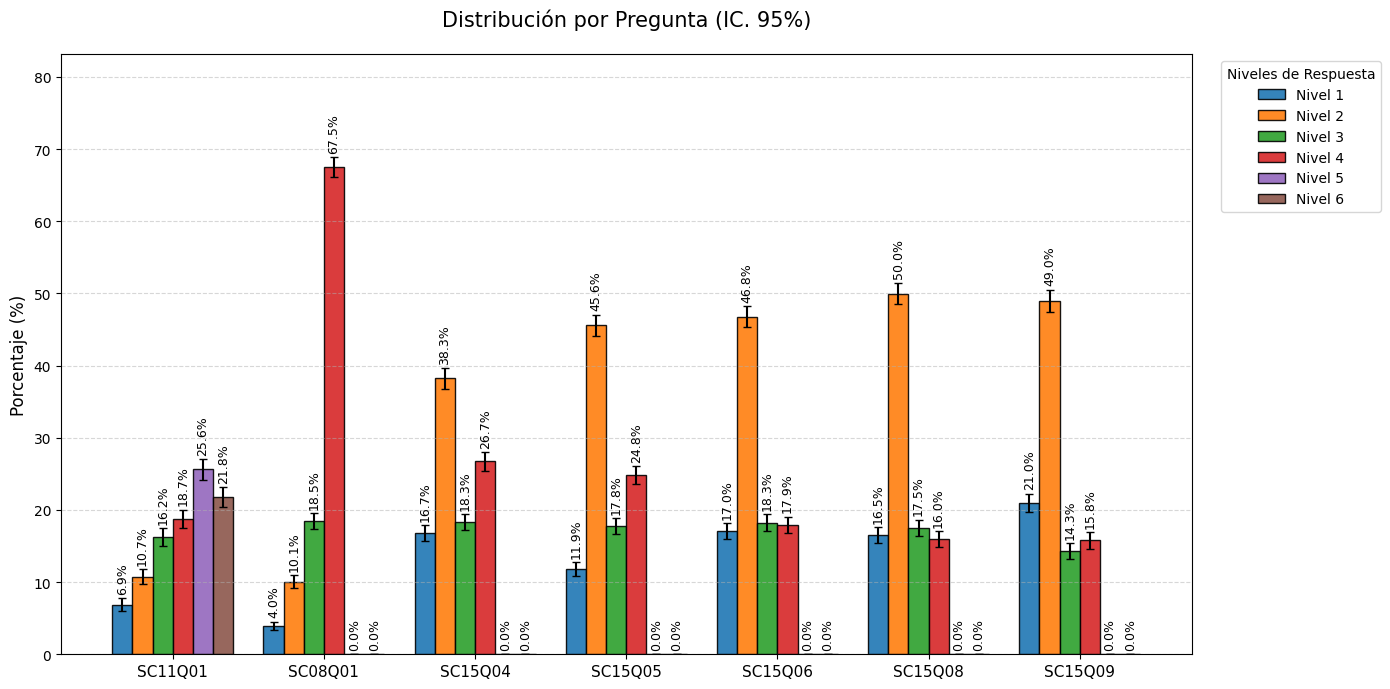

In [168]:
### Gráfica de variables categóricas ordinales (directores)
var_codes = df_vars_ht_selected[df_vars_ht_selected["TYPE"] == "CAT_ORD"]["NAME"].tolist()
plot_weighted_distrib(df=df_ht[df_ht["LEVEL2"]==1], var_list=var_codes, weight_col=wt_ht)

In [169]:
### Proporciones de variables categóricas ordinales (profesores)
var_codes = df_vars_te_selected[df_vars_te_selected["TYPE"] == "CAT_ORD"]["NAME"].tolist()
calc_weighted_ordinal(df=df_te[df_te["LEVEL"]==2], var_list=var_codes, weight_col=wt_te)

,TE07Q01,TE30Q01,TE09Q01,TE09Q02,TE09Q03,TE09Q04,TE09Q07,TE18Q07,TE20Q06,TE20Q13,TE20Q18,TE20Q21,TE20Q19,TE20Q20,TE23Q03,TE23Q04,TE23Q05,TE23Q06,TE23Q07,TE24Q01,TE24Q04,TE24Q11,TE24Q05,TE24Q07,TE24Q08
% 1,28.91,7.47,59.78,14.90,54.86,18.79,22.45,36.14,21.90,13.48,2.41,4.15,4.96,3.56,34.72,28.26,25.78,26.82,27.96,17.41,20.15,22.43,17.23,8.78,9.34
IC. Min. 1,27.62,6.71,58.23,13.87,53.33,17.66,21.24,34.70,20.70,12.48,1.95,3.55,4.32,3.02,33.35,26.96,24.51,25.55,26.67,16.32,18.99,21.22,16.12,7.93,8.47
IC. Max.1,30.21,8.23,61.33,15.92,56.39,19.91,23.66,37.58,23.09,14.49,2.87,4.75,5.60,4.11,36.09,29.56,27.04,28.10,29.25,18.50,21.31,23.64,18.34,9.63,10.22
% 2,16.35,12.06,12.79,15.45,23.99,35.03,18.64,45.07,35.60,38.25,26.15,21.54,31.29,31.89,43.67,43.11,38.01,45.84,38.87,71.69,67.44,66.22,71.15,59.15,65.13
IC. Min. 2,15.29,11.12,11.73,14.41,22.67,33.66,17.51,43.58,34.22,36.82,24.84,20.31,29.92,30.51,42.24,41.68,36.60,44.41,37.47,70.39,66.08,64.85,69.82,57.67,63.70
IC. Max.2,17.41,13.01,13.84,16.49,25.30,36.41,19.77,46.56,36.99,39.68,27.47,22.77,32.66,33.27,45.09,44.54,39.41,47.28,40.27,72.99,68.79,67.59,72.48,60.62,66.56
% 3,20.35,29.26,27.43,69.65,21.15,46.18,58.91,10.90,15.84,26.83,18.44,14.96,24.56,23.53,17.26,22.26,26.86,22.94,24.88,7.91,9.72,8.16,9.29,27.67,21.53
IC. Min. 3,19.20,27.95,26.02,68.32,19.89,44.75,57.48,9.97,14.79,25.52,17.28,13.89,23.29,22.28,16.17,21.06,25.58,21.73,23.63,7.13,8.87,7.37,8.44,26.33,20.29
IC. Max.3,21.50,30.58,28.85,70.97,22.41,47.62,60.34,11.84,16.90,28.13,19.60,16.02,25.84,24.79,18.34,23.46,28.15,24.15,26.12,8.68,10.58,8.96,10.14,29.01,22.76
% 4,13.15,17.24,NaN,NaN,NaN,NaN,NaN,7.89,26.66,21.44,53.00,59.35,39.18,41.02,4.36,6.36,9.35,4.40,8.30,3.00,2.69,3.19,2.33,4.40,4.00


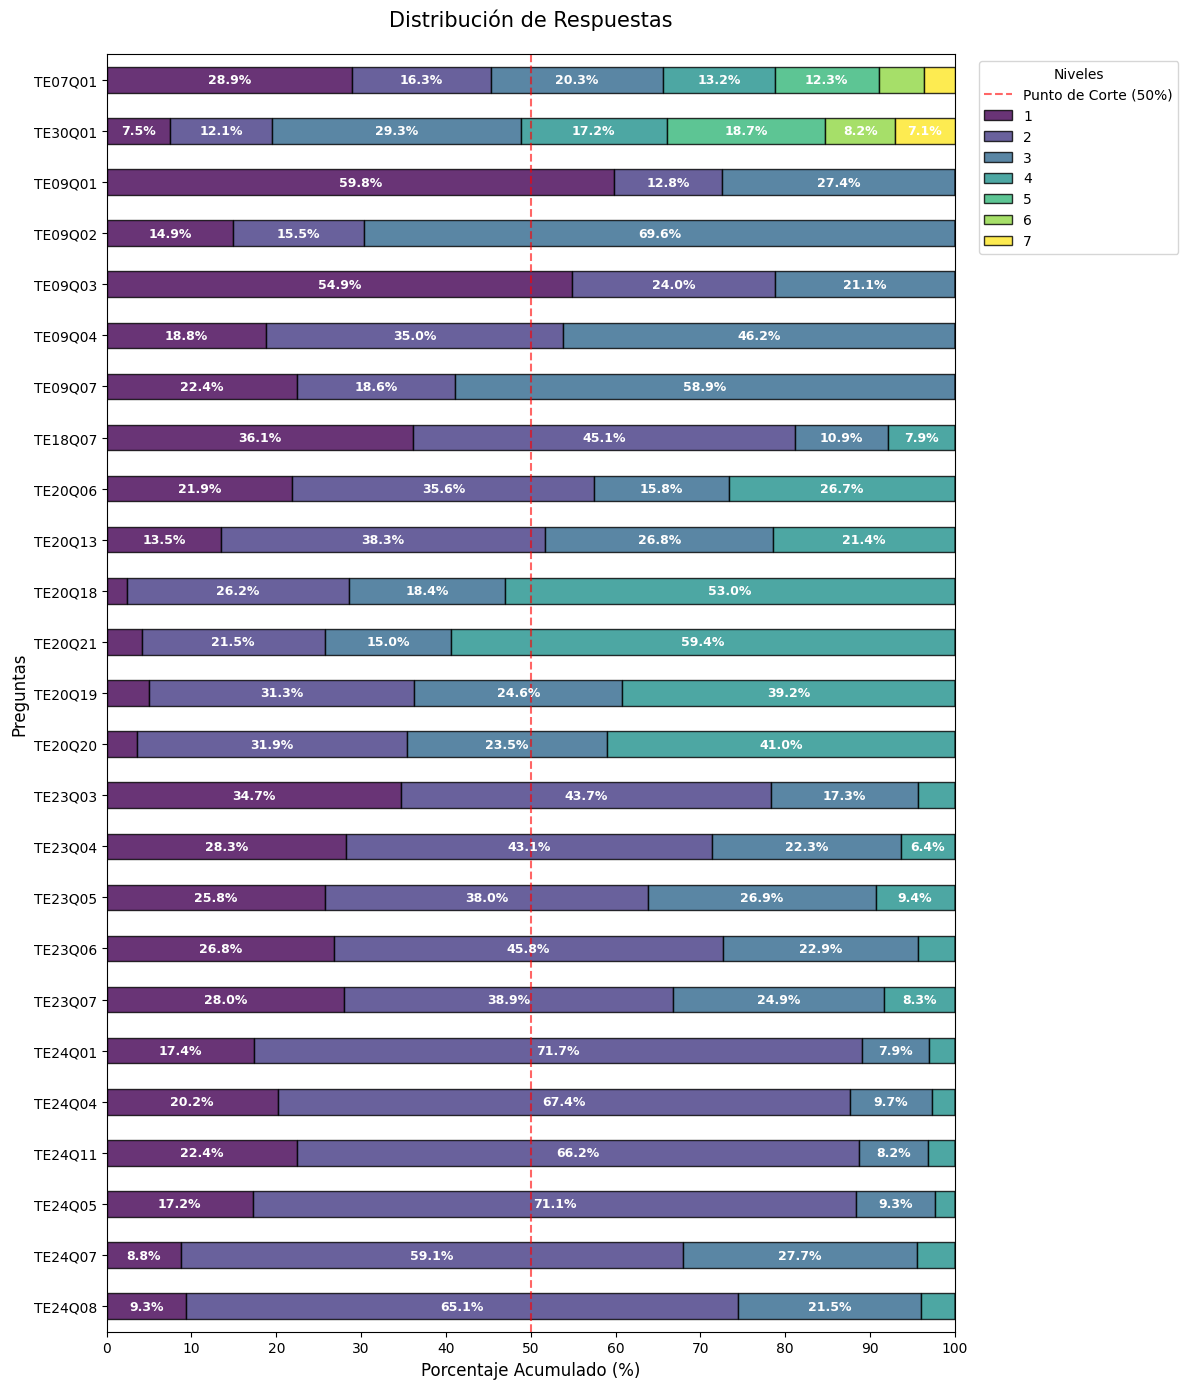

In [170]:
### Gráfica de variables categóricas ordinales para (profesores)
var_codes = df_vars_te_selected[df_vars_te_selected["TYPE"] == "CAT_ORD"]["NAME"].tolist()
plot_bars_stacked(df=df_te[df_te["LEVEL"]==2], var_list=var_codes, weight_col=wt_te)

In [171]:
### Proporciones de variables categóricas ordinales (estudiantes)
var_codes = df_vars_st_selected[df_vars_st_selected["TYPE"] == "CAT_ORD"]["NAME"].tolist()
calc_weighted_ordinal(df=df_st[df_st["LEVEL"]==2], var_list=var_codes, weight_col=wt_st)

,ST03Q01,ST03Q02,ST03Q14,ST03Q13,ST05Q03,ST05Q05,ST05Q06,ST05Q12,ST05Q01,ST05Q16,ST05Q02,ST05Q07,ST06Q02,ST06Q09,ST06Q04,ST06Q05,ST06Q18,ST06Q06,ST06Q07,ST06Q19,ST06Q01,ST06Q29,ST06Q15,ST08Q01,ST33Q01,ST33Q02,ST33Q04,ST15Q31,ST15Q06,ST15Q39,ST15Q43,ST17Q02
% 1,58.64,15.37,72.01,34.38,25.19,24.86,16.77,8.24,39.83,17.19,12.67,37.66,15.04,47.93,70.45,36.77,20.73,73.18,63.82,57.85,30.40,44.99,70.77,21.79,24.77,72.51,15.46,6.35,20.60,12.91,14.81,10.67
IC. Min. 1,58.04,14.94,71.46,33.80,24.66,24.33,16.32,7.91,39.24,16.73,12.27,37.07,14.61,47.32,69.89,36.19,20.24,72.63,63.23,57.25,29.84,44.38,70.21,21.29,24.25,71.97,15.03,6.03,20.07,12.46,14.34,10.28
IC. Max.1,59.24,15.81,72.57,34.96,25.71,25.38,17.23,8.58,40.43,17.64,13.07,38.25,15.48,48.55,71.01,37.36,21.23,73.72,64.40,58.46,30.96,45.60,71.33,22.29,25.29,73.06,15.90,6.67,21.13,13.36,15.28,11.06
% 2,9.16,11.15,9.35,13.70,20.23,27.18,23.99,10.50,25.26,4.98,5.22,25.52,25.40,22.83,14.08,16.11,13.86,19.08,10.56,11.61,28.27,23.58,13.01,22.57,23.08,8.40,19.70,18.56,19.10,19.82,21.84,15.82
IC. Min. 2,8.81,10.77,8.99,13.28,19.75,26.64,23.48,10.13,24.74,4.72,4.95,24.99,24.87,22.31,13.65,15.66,13.44,18.60,10.18,11.22,27.73,23.06,12.59,22.06,22.57,8.06,19.22,18.05,18.59,19.29,21.29,15.36
IC. Max.2,9.52,11.53,9.71,14.12,20.72,27.72,24.51,10.87,25.79,5.24,5.49,26.06,25.93,23.35,14.50,16.56,14.28,19.56,10.93,12.00,28.82,24.10,13.43,23.07,23.59,8.73,20.18,19.07,19.62,20.36,22.38,16.29
% 3,10.08,19.50,6.39,12.61,27.04,28.99,32.24,18.51,20.99,11.45,13.11,19.89,36.06,19.97,9.84,23.66,22.46,5.80,12.73,7.68,26.88,18.79,12.04,36.64,32.15,8.33,24.93,38.02,25.44,34.13,33.34,50.98
IC. Min. 3,9.71,19.03,6.09,12.21,26.50,28.44,31.67,18.04,20.50,11.06,12.70,19.40,35.47,19.47,9.48,23.14,21.96,5.51,12.32,7.35,26.34,18.31,11.63,36.05,31.59,8.00,24.41,37.39,24.87,33.49,32.71,50.35
IC. Max.3,10.45,19.98,6.69,13.02,27.58,29.54,32.81,18.98,21.49,11.83,13.52,20.38,36.64,20.46,10.20,24.18,22.97,6.08,13.13,8.00,27.42,19.27,12.44,37.22,32.72,8.67,25.45,38.66,26.01,34.77,33.96,51.62
% 4,22.12,53.97,12.25,39.31,27.54,18.97,26.99,62.75,13.91,66.39,69.01,16.92,23.50,9.27,5.63,23.46,42.94,1.95,12.90,22.85,14.44,12.64,4.18,19.01,19.99,10.76,39.91,37.06,34.85,33.13,30.02,22.52


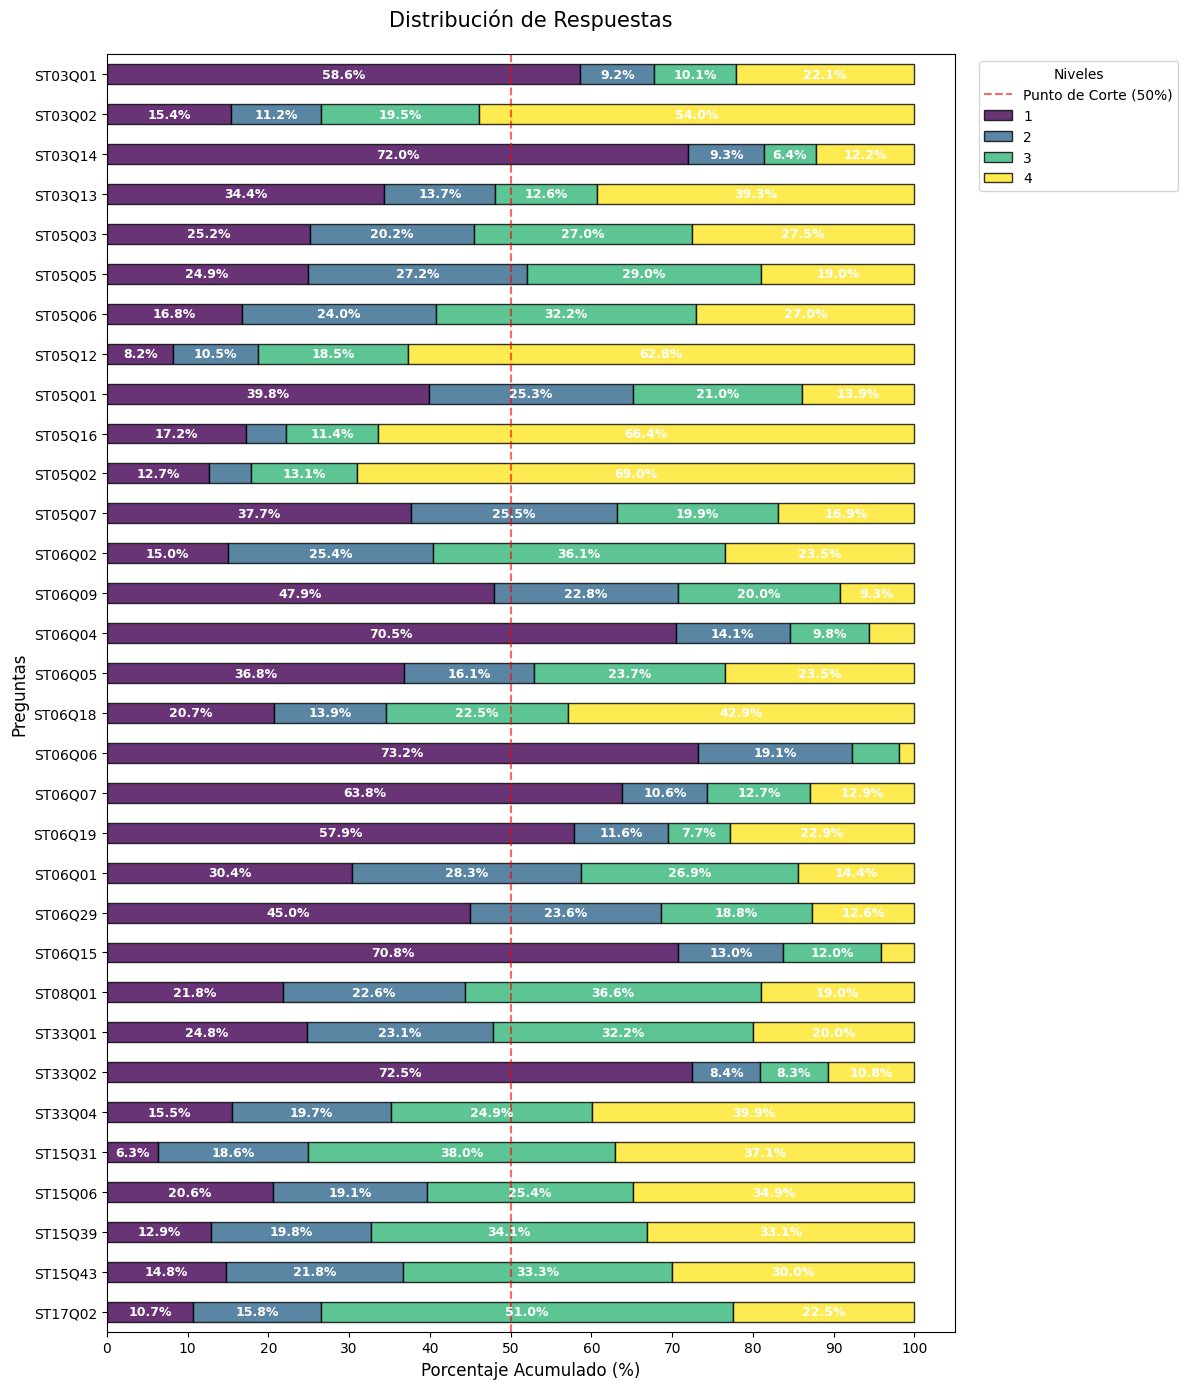

In [172]:
### Gráfica de variables categóricas ordinales (estudiantes)
var_codes = df_vars_st_selected[df_vars_st_selected["TYPE"] == "CAT_ORD"]["NAME"].tolist()
plot_bars_stacked(df=df_st[df_st["LEVEL"]==2], var_list=var_codes, weight_col=wt_st)

In [176]:
### Estadísticos para variables numéricas enteras (directores)
var_codes = df_vars_ht_selected[df_vars_ht_selected["TYPE"] == "NUM_INT"]["NAME"].tolist()
numerical_stats(df=df_ht[df_ht["LEVEL2"]==1], var_list=var_codes, weight_col=wt_ht)

,SC07Q01B,SC07Q01E,SC07Q03B,SC07Q03E,SC07Q07B,SC07Q07E
Media,43.77,107.95,31.52,59.89,10.88,20.51
IC_Min_95%,41.31,101.69,28.03,51.97,10.41,19.35
IC_Max_95%,46.23,114.21,35.01,67.81,11.36,21.67
Mediana,30.00,46.00,7.00,18.00,7.00,9.00
Desviación estándar,53.47,164.00,77.96,201.24,11.14,29.01
Sample_N,1816.00,2636.00,1918.00,2479.00,2099.00,2402.00


In [292]:
# WLS para determinar correlación de las variables categóricas ordinales de la encuesta de directores con datos PISA promedio
var_codes = df_vars_ht_selected[df_vars_ht_selected["TYPE"] == "CAT_ORD"]["NAME"].tolist()
corr_wls_ord_ht = pisa_correlation(df=df_ht[df_ht["LEVEL2"]==1], var_list=var_codes, pisa_col=pisa_avg, weight_col=wt_ht, var_type="CAT_ORD")
corr_wls_ord_ht

,Variable encuesta,Tipo,Coef. correlacion,P-valor,R cuadrado,Error estándar,IC. Min. 95%,IC. Max. 95%
0,SC11Q01,CAT_ORD,3.555804,2.196122e-32,0.040419,0.296999,2.973686,4.137923
1,SC08Q01,CAT_ORD,3.652361,4.815420e-36,0.033469,0.288886,3.086145,4.218577
2,SC15Q04,CAT_ORD,-0.971217,8.160702e-04,0.002560,0.289948,-1.539516,-0.402919
3,SC15Q05,CAT_ORD,-0.063705,8.238160e-01,0.000011,0.286116,-0.624492,0.497083
4,SC15Q06,CAT_ORD,1.290702,8.828612e-06,0.004653,0.290079,0.722148,1.859257
5,SC15Q08,CAT_ORD,-1.628741,6.074294e-08,0.006876,0.300158,-2.217052,-1.040431
6,SC15Q09,CAT_ORD,0.395173,1.636308e-01,0.000486,0.283640,-0.160761,0.951107


In [293]:
# WLS para determinar correlación de las variables categóricas dicotómicas de la encuesta de directores con datos PISA promedio
var_codes = df_vars_ht_selected[df_vars_ht_selected["TYPE"] == "CAT_DIC"]["NAME"].tolist()
corr_wls_dic_ht = pisa_correlation(df=df_ht[df_ht["LEVEL2"]==1], var_list=var_codes, pisa_col=pisa_avg, weight_col=wt_ht, var_type="CAT_DIC")
corr_wls_dic_ht

,Variable encuesta,Tipo,Coef. correlacion,P-valor,R cuadrado,Error estándar,IC. Min. 95%,IC. Max. 95%
0,SC12Q011,CAT_DIC,-4.783885,1.981820e-16,1.417804e-02,0.579650,-5.920000,-3.647771
1,SC12Q012,CAT_DIC,3.236585,2.152535e-06,4.730377e-03,0.682187,1.899498,4.573672
2,SC12Q013,CAT_DIC,-0.047719,9.310552e-01,1.580666e-06,0.551522,-1.128701,1.033264
3,SC12Q014,CAT_DIC,2.841619,1.940704e-06,4.772204e-03,0.596296,1.672879,4.010359
4,SC12Q015,CAT_DIC,-18.525594,3.901799e-24,2.145353e-02,1.818058,-22.088988,-14.962201
5,SC12Q016,CAT_DIC,-25.480017,2.625645e-27,2.444073e-02,2.339180,-30.064809,-20.895224
6,SC14Q02,CAT_DIC,-2.244929,3.725311e-03,1.811326e-03,0.773579,-3.761144,-0.728714
7,SC14Q03,CAT_DIC,-5.283190,7.408505e-22,2.036946e-02,0.547026,-6.355361,-4.211019
8,SC14Q06,CAT_DIC,-8.348156,6.200745e-50,4.823287e-02,0.554913,-9.435786,-7.260526
9,SC14Q13,CAT_DIC,-11.039783,3.070586e-78,7.438192e-02,0.578174,-12.173004,-9.906563


In [294]:
# WLS para determinar correlación de las variables numéricas enteras de la encuesta de directores con datos PISA promedio
var_codes = df_vars_ht_selected[df_vars_ht_selected["TYPE"] == "NUM_INT"]["NAME"].tolist()
corr_wls_int_ht = pisa_correlation(df=df_ht[df_ht["LEVEL2"]==1], var_list=var_codes, pisa_col=pisa_avg, weight_col=wt_ht, var_type="NUM_INT")
corr_wls_int_ht

,Variable encuesta,Tipo,Coef. correlacion,P-valor,R cuadrado,Error estándar,IC. Min. 95%,IC. Max. 95%
0,SC07Q01B,NUM_INT,4.491597,5.569663e-70,0.158393,0.243091,4.015138,4.968056
1,SC07Q01E,NUM_INT,2.563343,1.026047e-48,0.078483,0.171177,2.227836,2.898850
2,SC07Q03B,NUM_INT,3.376226,5.280042e-32,0.069821,0.281530,2.824427,3.928026
3,SC07Q03E,NUM_INT,1.458412,2.312349e-17,0.028610,0.170781,1.123682,1.793143
4,SC07Q07B,NUM_INT,-0.371295,1.114698e-01,0.001208,0.233183,-0.828333,0.085743
5,SC07Q07E,NUM_INT,2.365015,4.667581e-27,0.047227,0.216880,1.939931,2.790099


In [295]:
# WLS para determinar correlación de las variables categóricas ordinales de la encuesta de profesores con datos PISA promedio
var_codes = df_vars_te_selected[df_vars_te_selected["TYPE"] == "CAT_ORD"]["NAME"].tolist()
corr_wls_ord_te = pisa_correlation(df=df_te[df_te["LEVEL"]==2], var_list=var_codes, pisa_col=pisa_avg, weight_col=wt_te, var_type="CAT_ORD")
corr_wls_ord_te

,Variable encuesta,Tipo,Coef. correlacion,P-valor,R cuadrado,Error estándar,IC. Min. 95%,IC. Max. 95%
0,TE07Q01,CAT_ORD,1.400014,1.478073e-08,0.006789,0.246740,0.916404,1.883624
1,TE30Q01,CAT_ORD,-0.089878,7.437132e-01,0.000023,0.274892,-0.628666,0.448909
2,TE09Q01,CAT_ORD,2.167727,1.560554e-11,0.011779,0.320546,1.539457,2.795996
3,TE09Q02,CAT_ORD,-2.390402,4.737491e-19,0.017011,0.266872,-2.913471,-1.867334
4,TE09Q03,CAT_ORD,5.621496,1.092483e-69,0.074047,0.312445,5.009105,6.233888
5,TE09Q04,CAT_ORD,3.368551,1.675671e-35,0.032964,0.268599,2.842096,3.895006
6,TE09Q07,CAT_ORD,-2.275368,4.808216e-15,0.013421,0.289531,-2.842849,-1.707886
7,TE18Q07,CAT_ORD,0.311293,3.295451e-01,0.000223,0.319228,-0.314394,0.936980
8,TE20Q06,CAT_ORD,4.865900,8.580169e-70,0.065722,0.270854,4.335026,5.396774
9,TE20Q13,CAT_ORD,5.264744,8.270303e-76,0.073858,0.280259,4.715436,5.814053


In [296]:
# WLS para determinar correlación de las variables categóricas dicotómicas de la encuesta de profesores con datos PISA promedio
var_codes = df_vars_te_selected[df_vars_te_selected["TYPE"] == "CAT_DIC"]["NAME"].tolist()
corr_wls_dic_te = pisa_correlation(df=df_te[df_te["LEVEL"]==2], var_list=var_codes, pisa_col=pisa_avg, weight_col=wt_te, var_type="CAT_DIC")
corr_wls_dic_te

,Variable encuesta,Tipo,Coef. correlacion,P-valor,R cuadrado,Error estándar,IC. Min. 95%,IC. Max. 95%
0,TE04Q03,CAT_DIC,2.697917,1.216996e-06,0.005303,0.555175,1.609775,3.786060
1,TE05Q01,CAT_DIC,-9.187282,5.499189e-18,0.015344,1.058873,-11.262672,-7.111891
2,TE05Q03,CAT_DIC,-4.105100,2.157406e-06,0.004666,0.865346,-5.801178,-2.409022
3,TE05Q02,CAT_DIC,-3.492865,1.710567e-03,0.002049,1.113038,-5.674419,-1.311311
4,TE05Q04,CAT_DIC,4.960240,5.565113e-18,0.015710,0.571724,3.839660,6.080820
5,TE10Q01,CAT_DIC,-8.136014,4.483965e-37,0.033564,0.634058,-9.378767,-6.893261
6,TE10Q02,CAT_DIC,-9.209964,1.759285e-26,0.023604,0.859648,-10.894874,-7.525054
7,TE11Q01,CAT_DIC,-6.198528,4.703145e-11,0.009710,0.939670,-8.040281,-4.356776
8,TE11Q02,CAT_DIC,-8.516610,2.641940e-20,0.018933,0.917996,-10.315882,-6.717337
9,TE14Q04,CAT_DIC,6.734321,4.636384e-35,0.031814,0.540685,5.674578,7.794063


In [297]:
# WLS para determinar correlación de las variables categóricas ordinales de la encuesta de estudiantes con datos PISA promedio
var_codes = df_vars_st_selected[df_vars_st_selected["TYPE"] == "CAT_ORD"]["NAME"].tolist()
corr_wls_ord_st = pisa_correlation(df=df_st[df_st["LEVEL"]==2], var_list=var_codes, pisa_col=pisa_avg, weight_col=wt_st, var_type="CAT_ORD")
corr_wls_ord_st

,Variable encuesta,Tipo,Coef. correlacion,P-valor,R cuadrado,Error estándar,IC. Min. 95%,IC. Max. 95%
0,ST03Q01,CAT_ORD,2.361231,6.276301e-86,0.014951,0.119736,2.126548,2.595914
1,ST03Q02,CAT_ORD,4.352027,0.000000e+00,0.065077,0.101791,4.152517,4.551538
2,ST03Q14,CAT_ORD,0.799566,5.184923e-12,0.001878,0.115817,0.572566,1.026566
3,ST03Q13,CAT_ORD,3.150692,5.789981e-164,0.028417,0.114626,2.926025,3.375359
4,ST05Q03,CAT_ORD,0.441358,1.135458e-04,0.000570,0.114334,0.217263,0.665452
5,ST05Q05,CAT_ORD,2.779387,1.581023e-134,0.023190,0.111937,2.559991,2.998784
6,ST05Q06,CAT_ORD,1.259627,1.100115e-29,0.004926,0.111181,1.041713,1.477540
7,ST05Q12,CAT_ORD,4.047470,0.000000e+00,0.055262,0.103295,3.845012,4.249928
8,ST05Q01,CAT_ORD,2.654580,2.717878e-128,0.022067,0.109549,2.439863,2.869297
9,ST05Q16,CAT_ORD,3.228080,1.071171e-270,0.045967,0.090752,3.050206,3.405955


In [298]:
# WLS para determinar correlación de las variables categóricas dicotómicas de la encuesta de estudiantes con datos PISA promedio
var_codes = df_vars_st_selected[df_vars_st_selected["TYPE"] == "CAT_DIC"]["NAME"].tolist()
corr_wls_dic_st = pisa_correlation(df=df_st[df_st["LEVEL"]==2], var_list=var_codes, pisa_col=pisa_avg, weight_col=wt_st, var_type="CAT_DIC")
corr_wls_dic_st

,Variable encuesta,Tipo,Coef. correlacion,P-valor,R cuadrado,Error estándar,IC. Min. 95%,IC. Max. 95%
0,ST01Q01,CAT_DIC,-14.535404,0.000000e+00,0.087553,0.287122,-15.098163,-13.972644
1,ST01Q03,CAT_DIC,-0.401944,9.644905e-02,0.000104,0.241789,-0.875851,0.071962
2,ST02Q01,CAT_DIC,-15.916786,3.852799e-213,0.035418,0.506225,-16.908986,-14.924585
3,ST34Q01,CAT_DIC,2.784533,1.224878e-28,0.005527,0.250460,2.293630,3.275435
4,ST34Q02,CAT_DIC,-4.664340,6.830470e-81,0.016413,0.243858,-5.142302,-4.186378


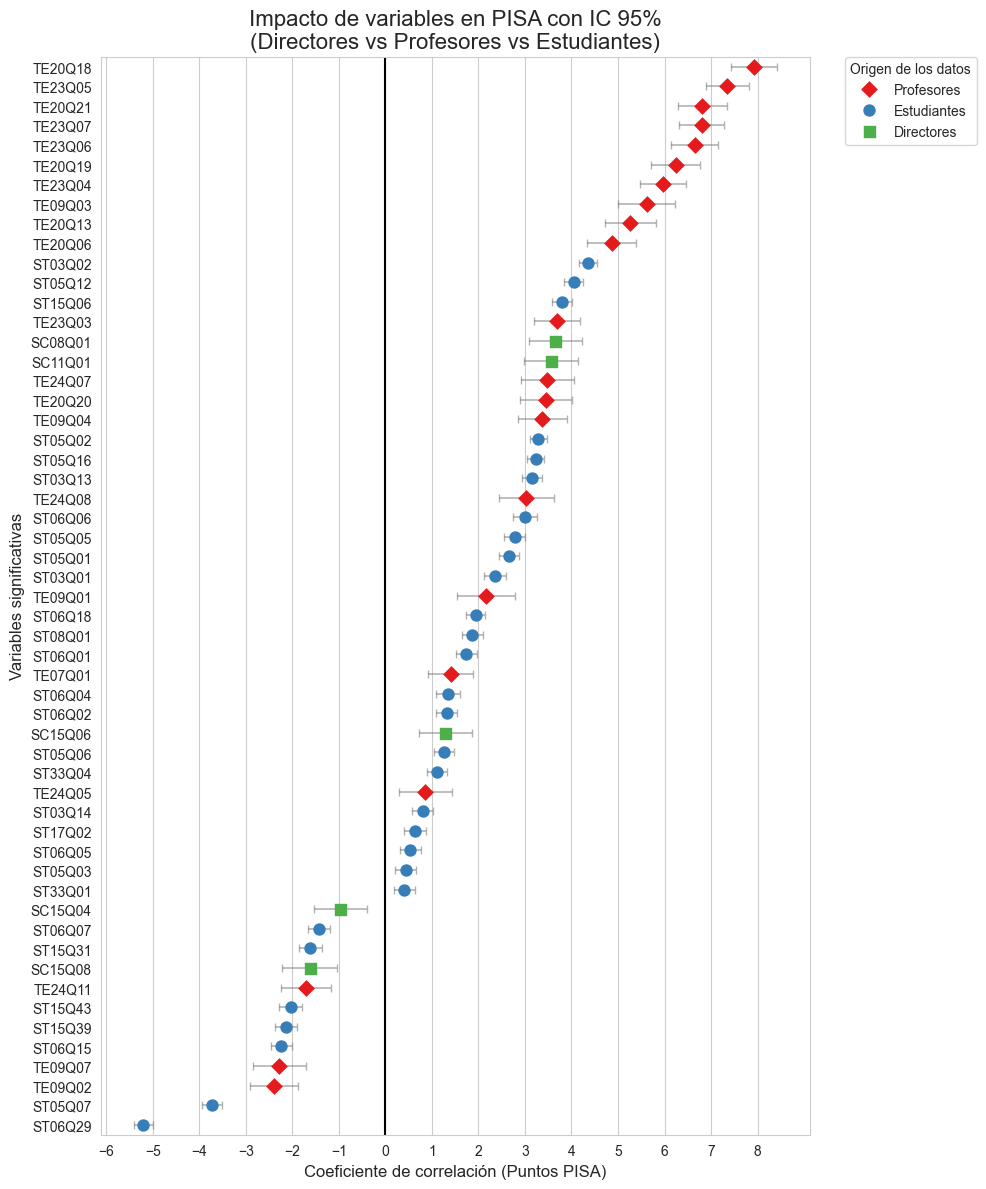

In [317]:
### Gráfica de correlación WLS para variables categóricas ordinales
wls_corr_plot(corr_wls_ord_ht, corr_wls_ord_te, corr_wls_ord_st)

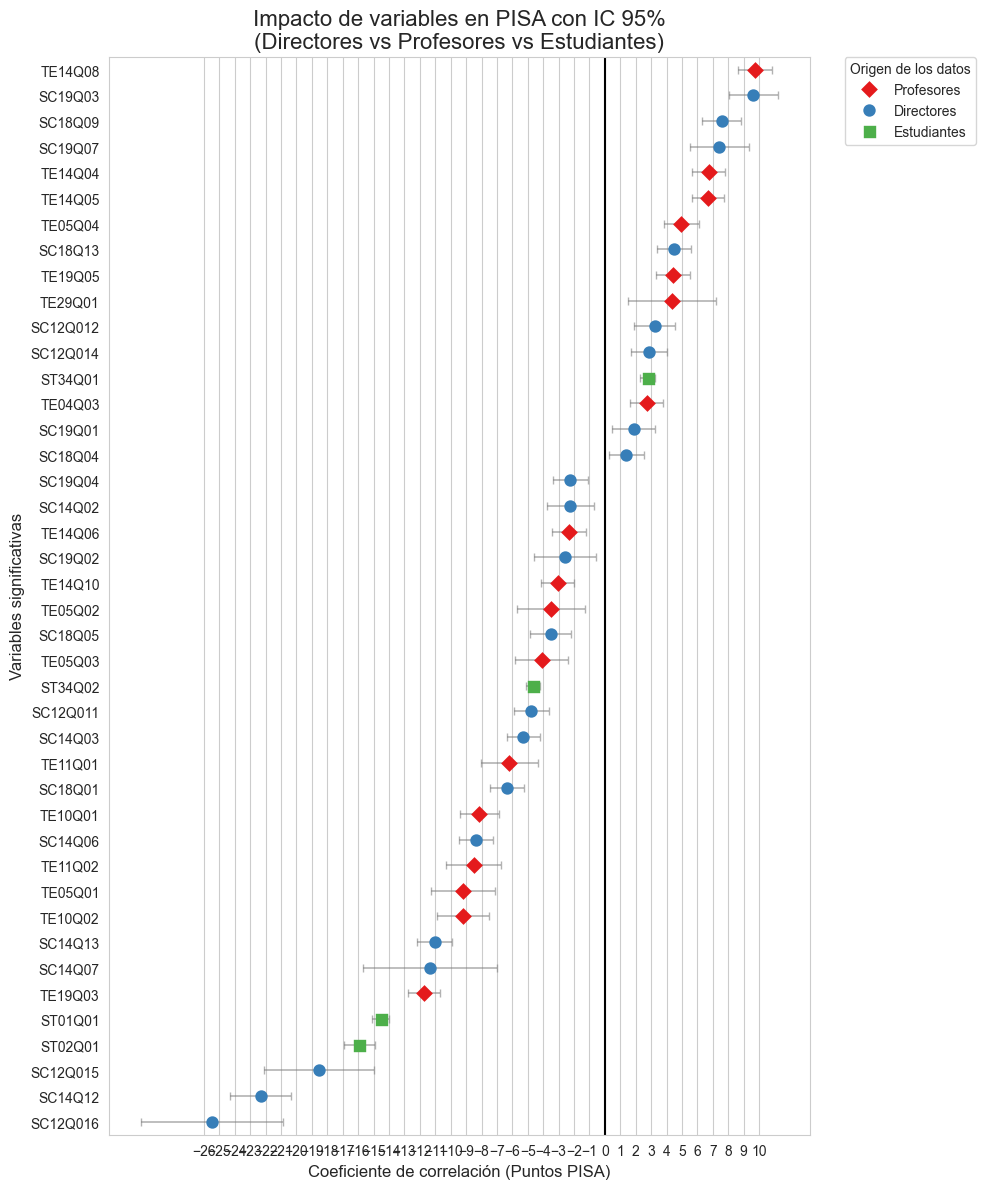

In [316]:
### Gráfica de correlación WLS para variables categóricas dicotomicas
wls_corr_plot(corr_wls_dic_ht, corr_wls_dic_te, corr_wls_dic_st)

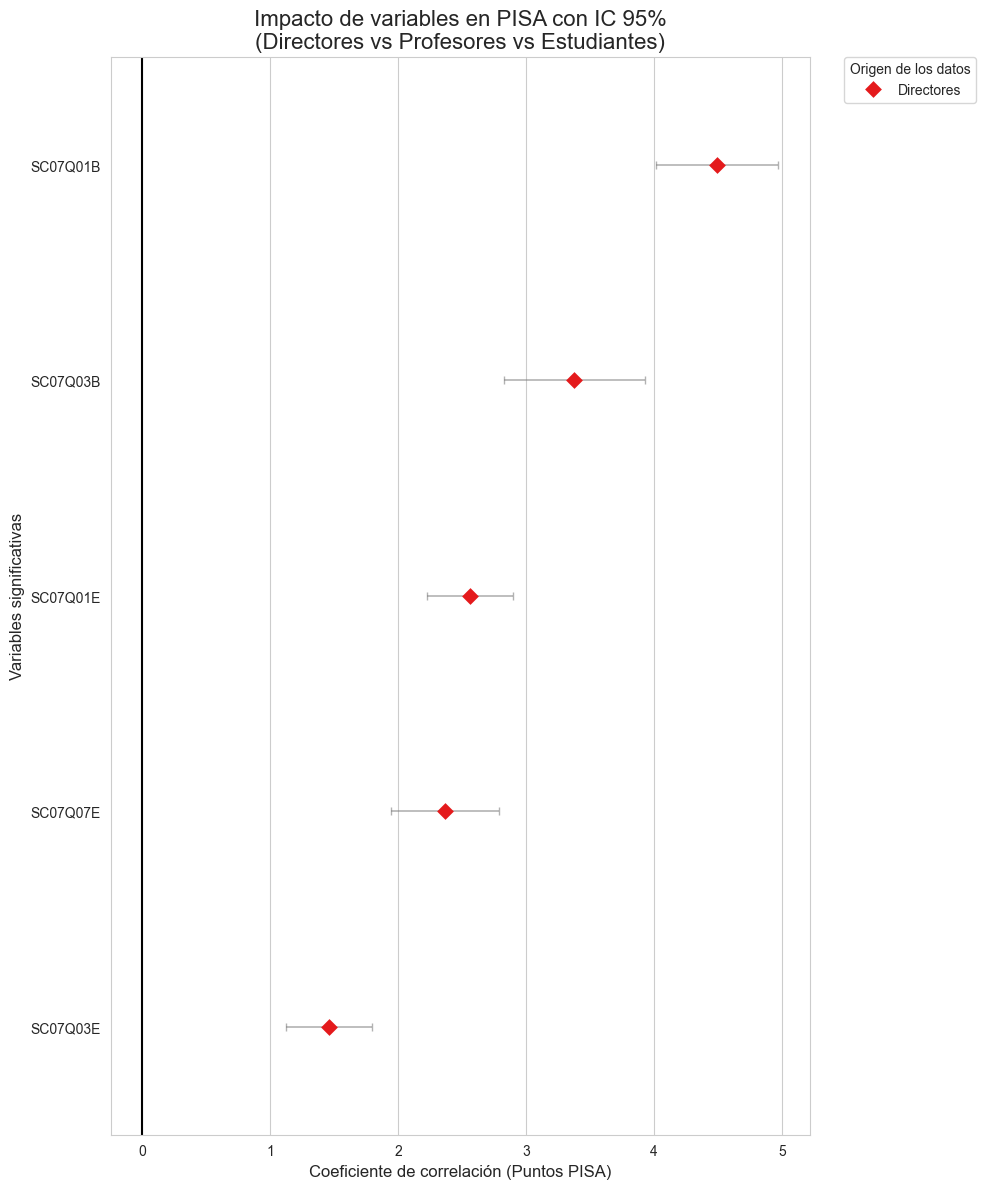

In [318]:
### Gráfica de correlación WLS para variables numéricas enteras
wls_corr_plot(corr_wls_int_ht, pd.DataFrame(), pd.DataFrame())

### Conteos 

In [230]:
print(df_ht.shape[0], df_te.shape[0], df_st.shape[0])
print(df_ht[df_ht["FSCWT_2"] != " "].shape[0], df_ht[df_ht["FSTWT_2"] != " "].shape[0], df_ht[df_ht["FSCWT"] != " "].shape[0], df_ht[df_ht["FSTWT"] != " "].shape[0])
print(df_ht[(df_ht["FSTWT_2"] != " ") & (df_ht["FSCWT_2"] != " ")].shape[0], df_ht[df_ht["FSTWT"] != " "].shape[0])
print(df_ht[(df_ht["FSTWT_2"] != " ") & (df_ht["LEVEL2"] == 1)].shape[0], df_ht[df_ht["FSTWT"] != " "].shape[0])
print(4739/8749*100)
print(df_te[(df_te["FSTWT"] != " ") & (df_te["LEVEL"] == 2)].shape[0], df_te.shape[0])
print(4860/9927*100)
print(df_st[(df_st["FSTWT"] != " ") & (df_st["LEVEL"] == 2)].shape[0], df_st.shape[0])
print(27251/48835*100)

8749 9927 48835
8749 8749 8749 8749
8749 8749
4739 8749
54.16619042176249
4860 9927
48.957388939256575
27251 48835
55.802191051499946
